# Task 3: Handwritten Character Recognition

## Handwritten Digit Recognition Using Convolutional Neural Network


### Objective

Identify handwritten digits from image data using image processing and deep learning.

### Approach

A Convolutional Neural Network (CNN) is trained on the MNIST handwritten digit dataset to classify images into digits from 0 to 9.

### Dataset

MNIST handwritten digit dataset.

### Model

Convolutional Neural Network (CNN).

### Key Features

- Image preprocessing and normalization
- CNN-based feature extraction
- Training and validation
- Model accuracy and loss evaluation
- Confusion matrix analysis
- Classification report
- Sample prediction visualization

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-Score

### Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Google Colab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


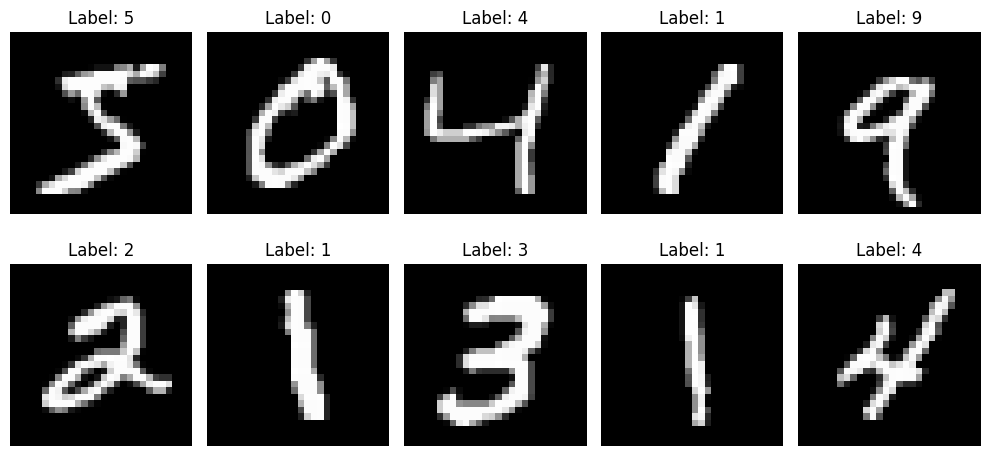

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Digit": unique,
    "Count": counts
})

class_distribution

,Digit,Count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


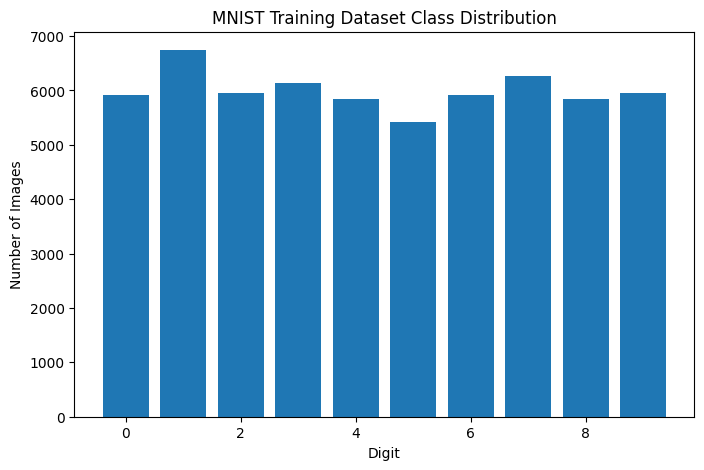

In [6]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Digit"],
    class_distribution["Count"]
)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Training Dataset Class Distribution")

plt.show()

In [7]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [9]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9195 - loss: 0.2630 - val_accuracy: 0.9850 - val_loss: 0.0510
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9733 - loss: 0.0894 - val_accuracy: 0.9892 - val_loss: 0.0371
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9803 - loss: 0.0639 - val_accuracy: 0.9902 - val_loss: 0.0328
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9836 - loss: 0.0543 - val_accuracy: 0.9905 - val_loss: 0.0317
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9872 - loss: 0.0450 - val_accuracy: 0.9923 - val_loss: 0.0300
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9881 - loss: 0.0383 - val_accuracy: 0.9927 - val_loss: 0.0302
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9899 - loss: 0.0320 - val_accuracy: 0.9933 - val_loss: 0.0289
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9906 - loss: 0.0284 - 

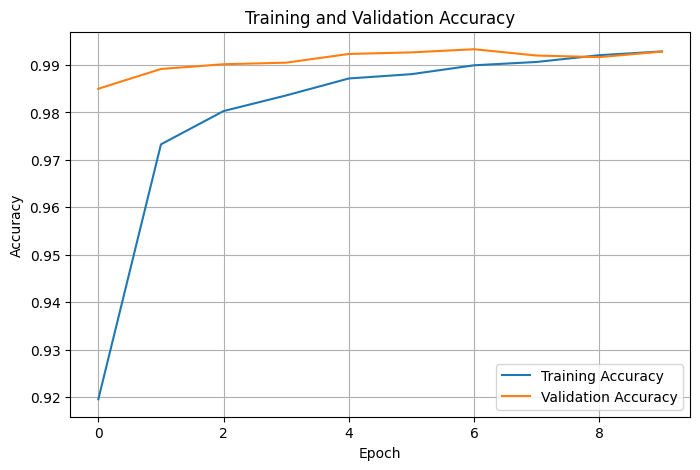

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

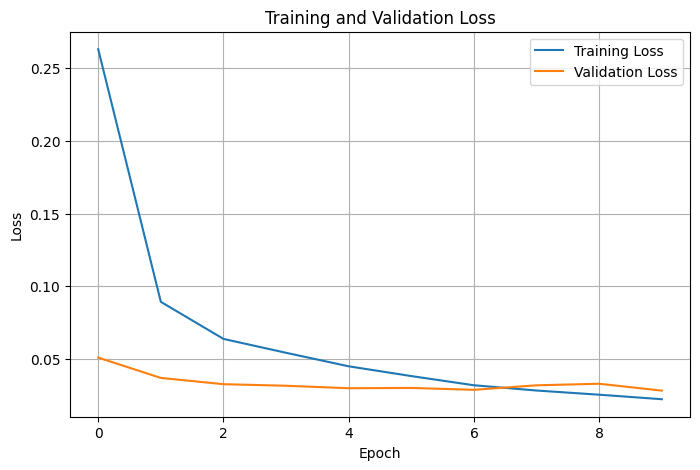

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.024014156311750412
Test Accuracy: 0.992900013923645


In [15]:
y_prob = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9929
Precision: 0.9929230072898172
Recall   : 0.9929
F1-Score : 0.9928987152762091


In [17]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



<Figure size 900x700 with 0 Axes>

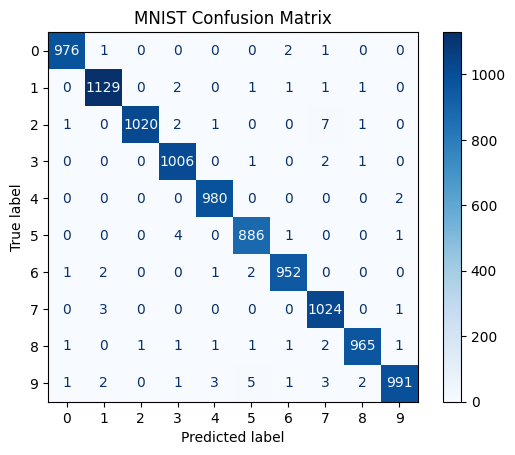

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("MNIST Confusion Matrix")
plt.show()

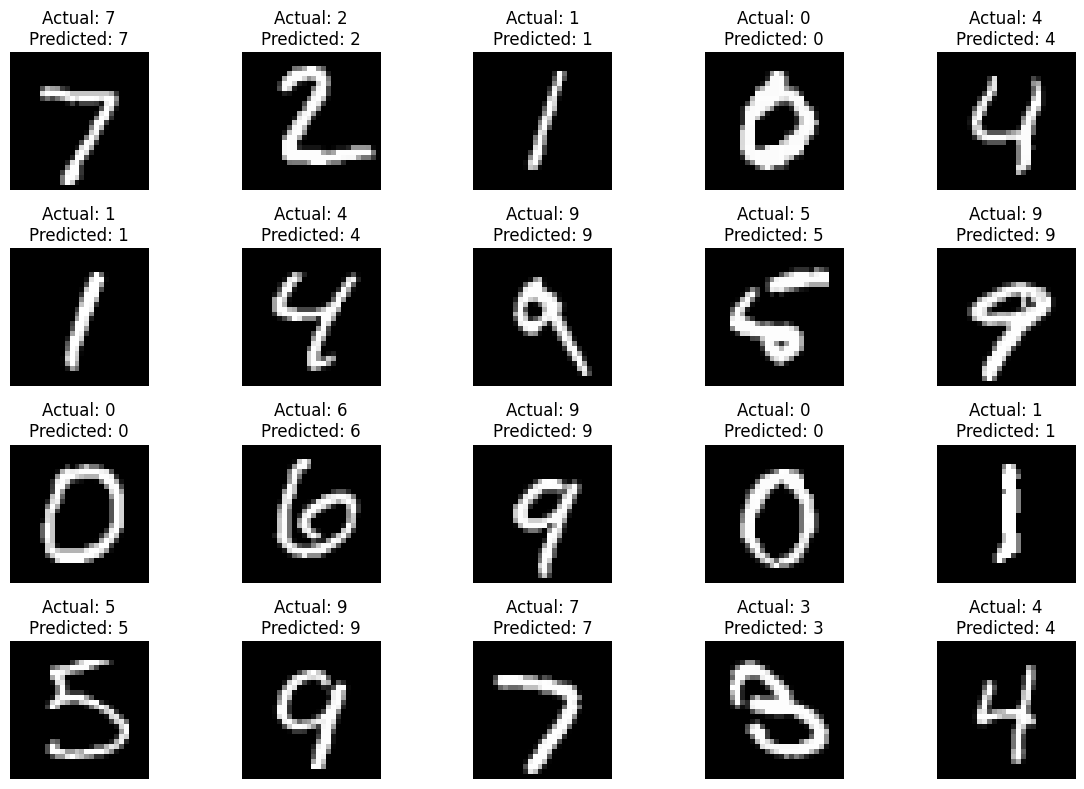

In [19]:
plt.figure(figsize=(12, 8))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
misclassified = np.where(
    y_pred != y_test
)[0]

print(
    "Number of misclassified images:",
    len(misclassified)
)

Number of misclassified images: 71


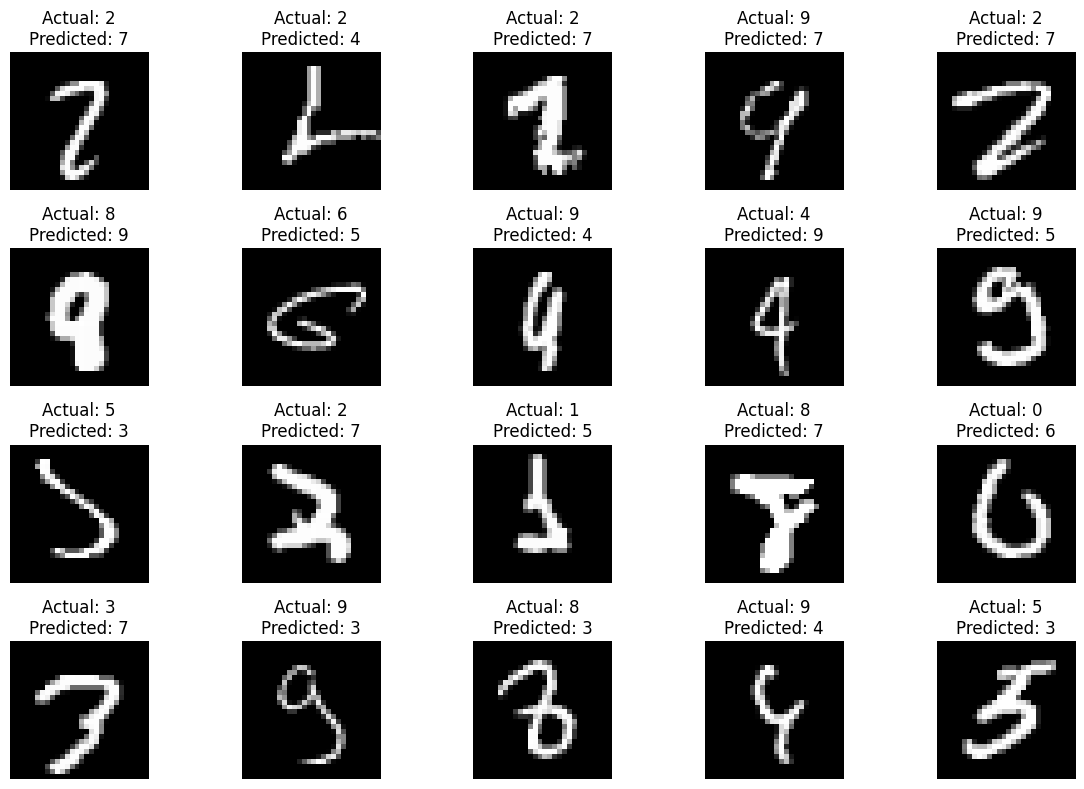

In [21]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(misclassified[:20]):

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Accuracy,0.992900
1,Precision,0.992923
2,Recall,0.992900
3,F1-Score,0.992899


In [23]:
results.to_csv(
    "mnist_cnn_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [24]:
model.save(
    "mnist_cnn_model.keras"
)

print("CNN model saved successfully.")

CNN model saved successfully.


# Project Summary

This project implements a Convolutional Neural Network (CNN) for handwritten digit recognition using the MNIST dataset.

The dataset contains 60,000 training images and 10,000 testing images, with each image having dimensions of 28 × 28 pixels.

The workflow includes:

1. Loading the MNIST dataset
2. Exploring and visualizing handwritten digits
3. Checking class distribution
4. Normalizing pixel values
5. Reshaping images for CNN input
6. Building a CNN architecture
7. Training the model
8. Evaluating test performance
9. Calculating Accuracy, Precision, Recall, and F1-Score
10. Generating a confusion matrix
11. Visualizing correct and incorrect predictions
12. Saving model evaluation results
13. Saving the trained CNN model

The project demonstrates how convolutional neural networks can automatically learn visual features from handwritten images and classify them into their corresponding digit classes.

### Disclaimer

This project is developed for educational and machine learning experimentation purposes.